In [1]:
!nvidia-smi

Fri Nov 28 15:11:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


In [3]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.1/516.1 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [5]:
# @title Load model

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [6]:
# @title Run inference

URL = "https://media.roboflow.com/notebooks/examples/dog.jpeg"

image = Image.open(requests.get(URL, stream=True).raw)
inputs = processor(image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

w, h = image.size
results = processor.post_process_object_detection(
    outputs, target_sizes=[(h, w)], threshold=0.3)

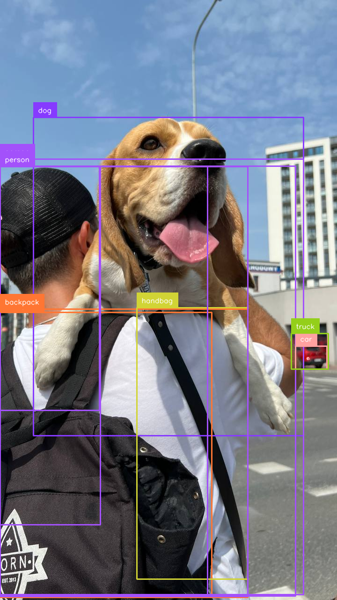

In [7]:
detections = sv.Detections.from_transformers(results[0])
labels = [
    model.config.id2label[class_id]
    for class_id
    in detections.class_id
]

annotated_image = image.copy()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
annotated_image = box_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels=labels)
annotated_image.thumbnail((600, 600))
annotated_image

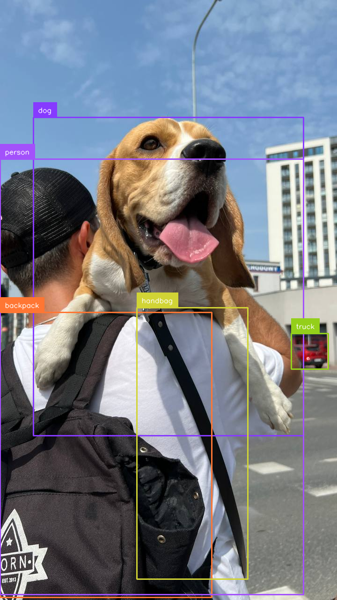

In [8]:
detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)
labels = [
    model.config.id2label[class_id]
    for class_id
    in detections.class_id
]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels=labels)
annotated_image.thumbnail((600, 600))
annotated_image

## Fine-tune RT-DETR on custom dataset

In [9]:
# @title Download dataset from Roboflow Universe

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("poker-cards-fmjio")
version = project.version(4)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to poker-cards-4 in coco:: 100%|██████████| 907/907 [00:00<00:00, 3106.57it/s]


In [10]:
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 811
Number of validation images: 44
Number of test images: 44


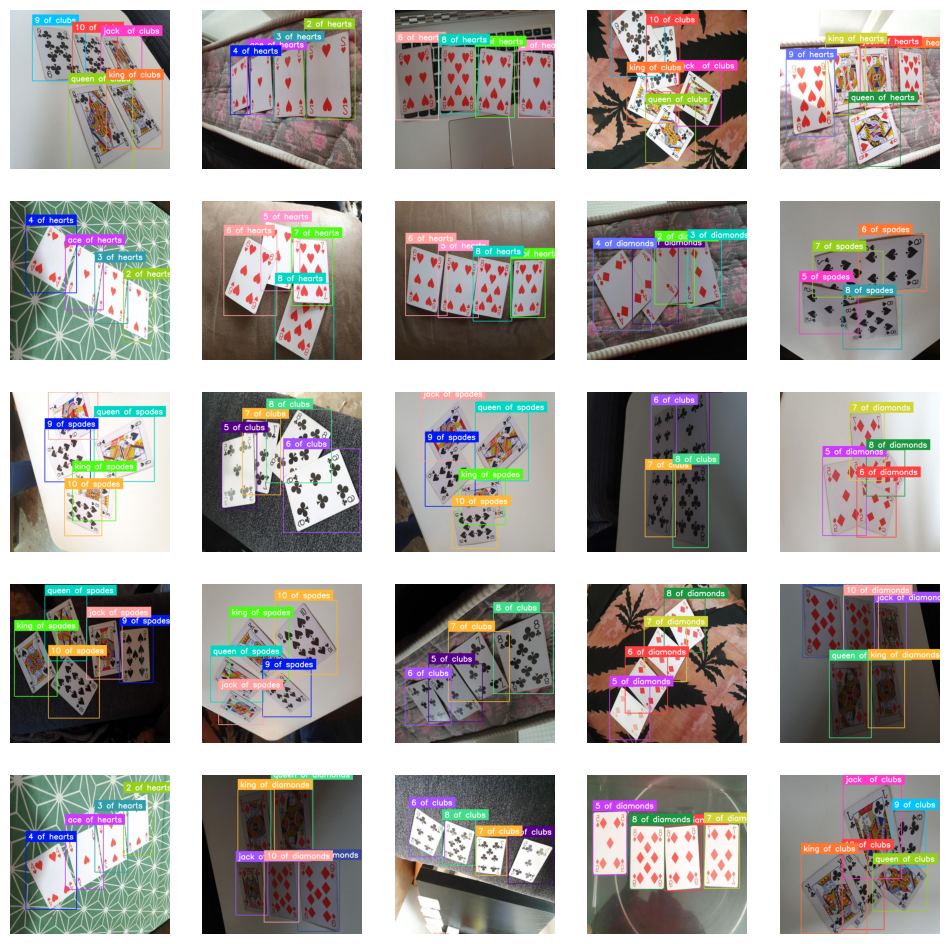

In [11]:
# @title Display dataset sample

GRID_SIZE = 5

def annotate(image, annotations, classes):
    labels = [
        classes[class_id]
        for class_id
        in annotations.class_id
    ]

    # Change BoundingBoxAnnotator to BoxAnnotator
    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=2)

    annotated_image = image.copy()
    annotated_image = bounding_box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels=labels)
    return annotated_image

annotated_images = []
for i in range(GRID_SIZE * GRID_SIZE):
    _, image, annotations = ds_train[i]
    annotated_image = annotate(image, annotations, ds_train.classes)
    annotated_images.append(annotated_image)

sv.plot_images_grid(
    images=annotated_images,
    grid_size=(GRID_SIZE, GRID_SIZE)
)

### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [12]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [13]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

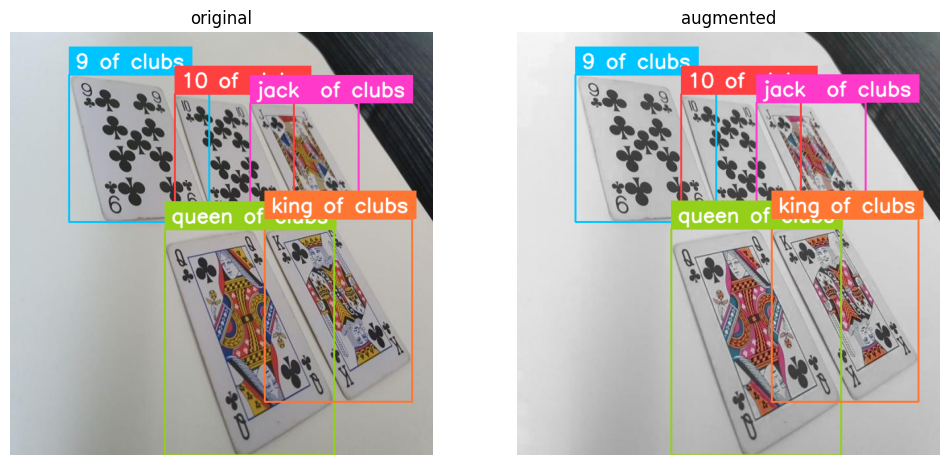

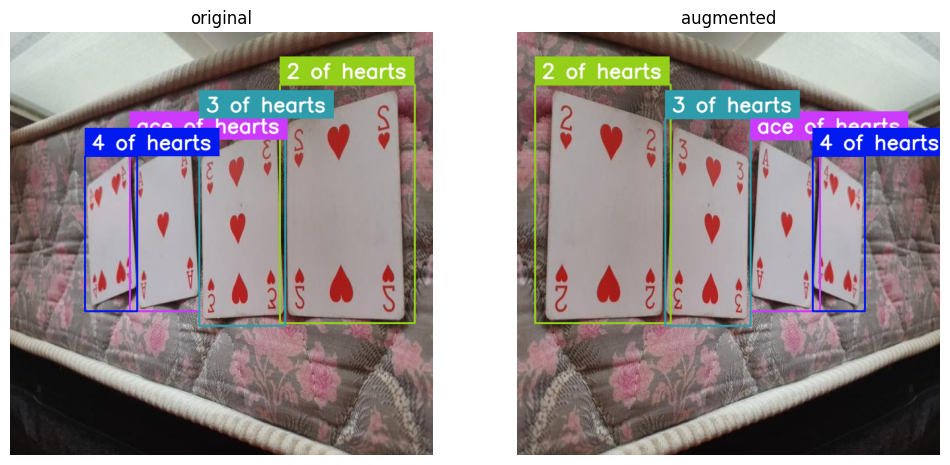

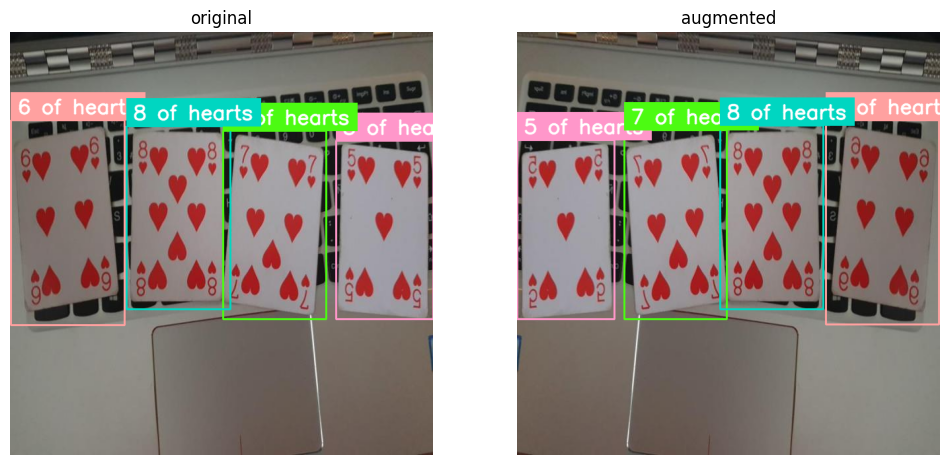

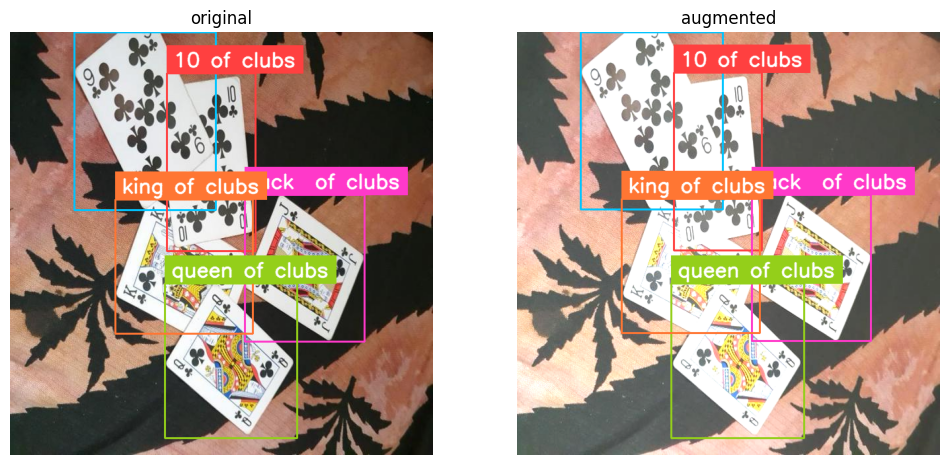

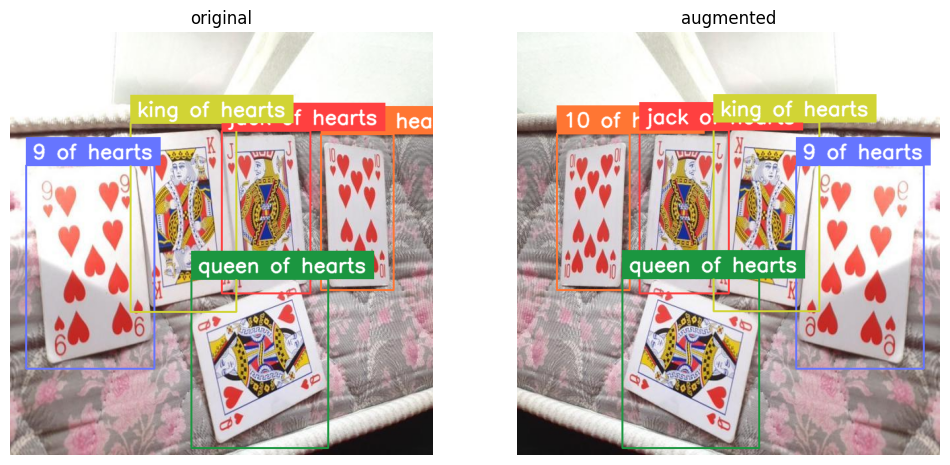

In [14]:
# @title Visualize some augmented images

IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]

    augmented_annotations_xyxy = np.array(output["bboxes"])
    augmented_annotations_class_id = np.array(output["category"])

    augmented_data = {}
    if len(augmented_annotations_xyxy) > 0:
        # Ensure 'iscrowd' matches the new number of detections
        if 'iscrowd' in annotations.data:
            augmented_data['iscrowd'] = np.zeros(len(augmented_annotations_xyxy), dtype=int)
        # Copy other non-per-detection data from original annotations
        for key, value in annotations.data.items():
            if key not in augmented_data and not (isinstance(value, np.ndarray) and value.shape[0] == len(annotations.xyxy)):
                augmented_data[key] = value

    augmented_annotations = replace(
        annotations,
        xyxy=augmented_annotations_xyxy,
        class_id=augmented_annotations_class_id,
        data=augmented_data
    )

    annotated_images = [
        annotate(image, annotations, ds_train.classes),
        annotate(augmented_image, augmented_annotations, ds_train.classes)
    ]
    sv.plot_images_grid(
        images=annotated_images,
        grid_size=(1, 2),
        titles=['original', 'augmented']
    )

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [15]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [16]:
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.1843, 0.1843, 0.1804,  ..., 0.0235, 0.0235, 0.0235],
          [0.1922, 0.1922, 0.1882,  ..., 0.0235, 0.0235, 0.0235],
          [0.1961, 0.1961, 0.1961,  ..., 0.0235, 0.0235, 0.0196],
          ...,
          [0.0039, 0.0078, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0078, 0.0157, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
          [0.0078, 0.0157, 0.0078,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.2510, 0.2510, 0.2471,  ..., 0.0078, 0.0078, 0.0078],
          [0.2588, 0.2588, 0.2549,  ..., 0.0078, 0.0078, 0.0078],
          [0.2627, 0.2627, 0.2627,  ..., 0.0039, 0.0039, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.3216, 0.3216, 0.3176,  ..., 0.0000, 0.0000, 0.0000],
          [0.3294, 0.3294, 0.3255,  ..., 0.0000, 0.0000, 0.0000],
          [0.3333, 0.333

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [17]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [18]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [19]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                       
----------------------------------------------------+----------+---------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80]) vs model:torch.Size([53])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80, 256]) vs model:torch.Size([53, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81, 256]) vs model:torch.Size([54, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([80, 256]) vs model:torch.Size([53, 256])
model.enc_scor

In [70]:
training_args = TrainingArguments(
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=20,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [71]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Cards,Mar 100 Cards,Map 10 of clubs,Mar 100 10 of clubs,Map 10 of diamonds,Mar 100 10 of diamonds,Map 10 of hearts,Mar 100 10 of hearts,Map 10 of spades,Mar 100 10 of spades,Map 2 of clubs,Mar 100 2 of clubs,Map 2 of diamonds,Mar 100 2 of diamonds,Map 2 of hearts,Mar 100 2 of hearts,Map 2 of spades,Mar 100 2 of spades,Map 3 of clubs,Mar 100 3 of clubs,Map 3 of diamonds,Mar 100 3 of diamonds,Map 3 of hearts,Mar 100 3 of hearts,Map 3 of spades,Mar 100 3 of spades,Map 4 of clubs,Mar 100 4 of clubs,Map 4 of diamonds,Mar 100 4 of diamonds,Map 4 of hearts,Mar 100 4 of hearts,Map 4 of spades,Mar 100 4 of spades,Map 5 of clubs,Mar 100 5 of clubs,Map 5 of diamonds,Mar 100 5 of diamonds,Map 5 of hearts,Mar 100 5 of hearts,Map 5 of spades,Mar 100 5 of spades,Map 6 of clubs,Mar 100 6 of clubs,Map 6 of diamonds,Mar 100 6 of diamonds,Map 6 of hearts,Mar 100 6 of hearts,Map 6 of spades,Mar 100 6 of spades,Map 7 of clubs,Mar 100 7 of clubs,Map 7 of diamonds,Mar 100 7 of diamonds,Map 7 of hearts,Mar 100 7 of hearts,Map 7 of spades,Mar 100 7 of spades,Map 8 of clubs,Mar 100 8 of clubs,Map 8 of diamonds,Mar 100 8 of diamonds,Map 8 of hearts,Mar 100 8 of hearts,Map 8 of spades,Mar 100 8 of spades,Map 9 of clubs,Mar 100 9 of clubs,Map 9 of diamonds,Mar 100 9 of diamonds,Map 9 of hearts,Mar 100 9 of hearts,Map 9 of spades,Mar 100 9 of spades,Map Ace of clubs,Mar 100 Ace of clubs,Map Ace of diamonds,Mar 100 Ace of diamonds,Map Ace of hearts,Mar 100 Ace of hearts,Map Ace of spades,Mar 100 Ace of spades,Map Jack of clubs,Mar 100 Jack of clubs,Map Jack of diamonds,Mar 100 Jack of diamonds,Map Jack of hearts,Mar 100 Jack of hearts,Map Jack of spades,Mar 100 Jack of spades,Map King of clubs,Mar 100 King of clubs,Map King of diamonds,Mar 100 King of diamonds,Map King of hearts,Mar 100 King of hearts,Map King of spades,Mar 100 King of spades,Map Queen of clubs,Mar 100 Queen of clubs,Map Queen of diamonds,Mar 100 Queen of diamonds,Map Queen of hearts,Mar 100 Queen of hearts,Map Queen of spades,Mar 100 Queen of spades
1,No log,4.830186,0.902800,0.987800,0.983000,-1.000000,-1.000000,0.902900,0.918400,0.933000,0.935800,-1.000000,-1.000000,0.935800,-1.000000,-1.000000,0.944200,0.966700,0.977700,0.983300,0.893900,0.900000,0.746500,0.800000,1.000000,1.000000,1.000000,1.000000,0.900000,0.900000,0.913500,0.950000,1.000000,1.000000,0.900000,0.900000,0.900000,0.900000,0.711100,0.925000,1.000000,1.000000,1.000000,1.000000,0.900000,0.900000,0.700800,0.850000,0.847400,0.962500,0.944200,0.966700,0.811000,0.866700,1.000000,1.000000,1.000000,1.000000,0.955400,0.966700,0.900400,0.933300,0.900000,0.900000,0.901100,0.985700,1.000000,1.000000,0.732700,0.800000,0.933300,1.000000,0.971100,0.985700,0.933700,0.933300,0.845700,0.900000,0.900000,0.900000,1.000000,1.000000,0.985100,0.985700,0.845500,0.857100,0.838900,0.875000,1.000000,1.000000,0.825200,0.850000,0.814300,1.000000,0.894800,0.900000,1.000000,1.000000,0.985100,0.985700,0.745100,0.883300,0.676200,0.675000,1.000000,1.000000,0.868100,0.985700,0.924100,0.928600,0.850500,0.850000,0.966300,0.966700,1.000000,1.000000,0.921300,0.942900,0.740500,0.900000
2,No log,4.883755,0.899400,0.988500,0.982600,-1.000000,-1.000000,0.899500,0.920200,0.926200,0.928400,-1.000000,-1.000000,0.928400,-1.000000,-1.000000,0.955400,0.966700,0.980400,0.983300,0.869600,0.900000,0.746500,0.800000,0.925200,0.950000,1.000000,1.000000,0.900000,0.900000,0.926700,0.950000,1.000000,1.000000,0.900000,0.900000,0.900000,0.900000,0.758600,0.925000,1.000000,1.000000,1.000000,1.000000,0.900000,0.900000,0.740000,0.850000,0.837700,0.950000,0.944200,0.966700,0.833000,0.866700,1.000000,1.000000,1.000000,1.000000,0.955400,0.966700,0.900000,0.900000,0.900000,0.900000,0.904300,0.971400,1.000000,1.000000,0.732700,0.800000,0.900000,0.900000,0.971500,0.985700,0.933700,0.933300,0.844200,0.866700,0.900000,0.900000,1.000000,1.000000,0.98510

TrainOutput(global_step=1020, training_loss=7.420646443086512, metrics={'train_runtime': 1783.2234, 'train_samples_per_second': 9.096, 'train_steps_per_second': 0.572, 'total_flos': 2.880536719905792e+18, 'train_loss': 7.420646443086512, 'epoch': 20.0})

In [1]:
import matplotlib.pyplot as plt

# Extract log history from the trainer
log_history = trainer.state.log_history

# Filter out entries that contain mAP metrics
eval_maps = [entry['eval_map'] for entry in log_history if 'eval_map' in entry]
eval_map50s = [entry['eval_map_50'] for entry in log_history if 'eval_map_50' in entry]
eval_map75s = [entry['eval_map_75'] for entry in log_history if 'eval_map_75' in entry]
epochs_eval_map = [entry['epoch'] for entry in log_history if 'eval_map' in entry]

# Plot the mAP metrics
plt.figure(figsize=(10, 6))

if eval_maps:
    plt.plot(epochs_eval_map, eval_maps, label='mAP')
if eval_map50s:
    plt.plot(epochs_eval_map, eval_map50s, label='mAP50')
if eval_map75s:
    plt.plot(epochs_eval_map, eval_map75s, label='mAP75')

plt.title('Mean Average Precision (mAP) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP Value')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'trainer' is not defined

In [2]:
import matplotlib.pyplot as plt

# Extract log history from the trainer
log_history = trainer.state.log_history

# Filter out entries that contain 'loss' and 'eval_loss'
train_losses = [entry['loss'] for entry in log_history if 'loss' in entry]
eval_losses = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
epochs_train = [entry['epoch'] for entry in log_history if 'loss' in entry]
epochs_eval = [entry['epoch'] for entry in log_history if 'eval_loss' in entry]

# Plot the losses
plt.figure(figsize=(10, 6))

if train_losses:
    plt.plot(epochs_train, train_losses, label='Training Loss')
if eval_losses:
    plt.plot(epochs_eval, eval_losses, label='Validation Loss')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'trainer' is not defined

In [66]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [67]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.34
map50: 0.35
map75: 0.35


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


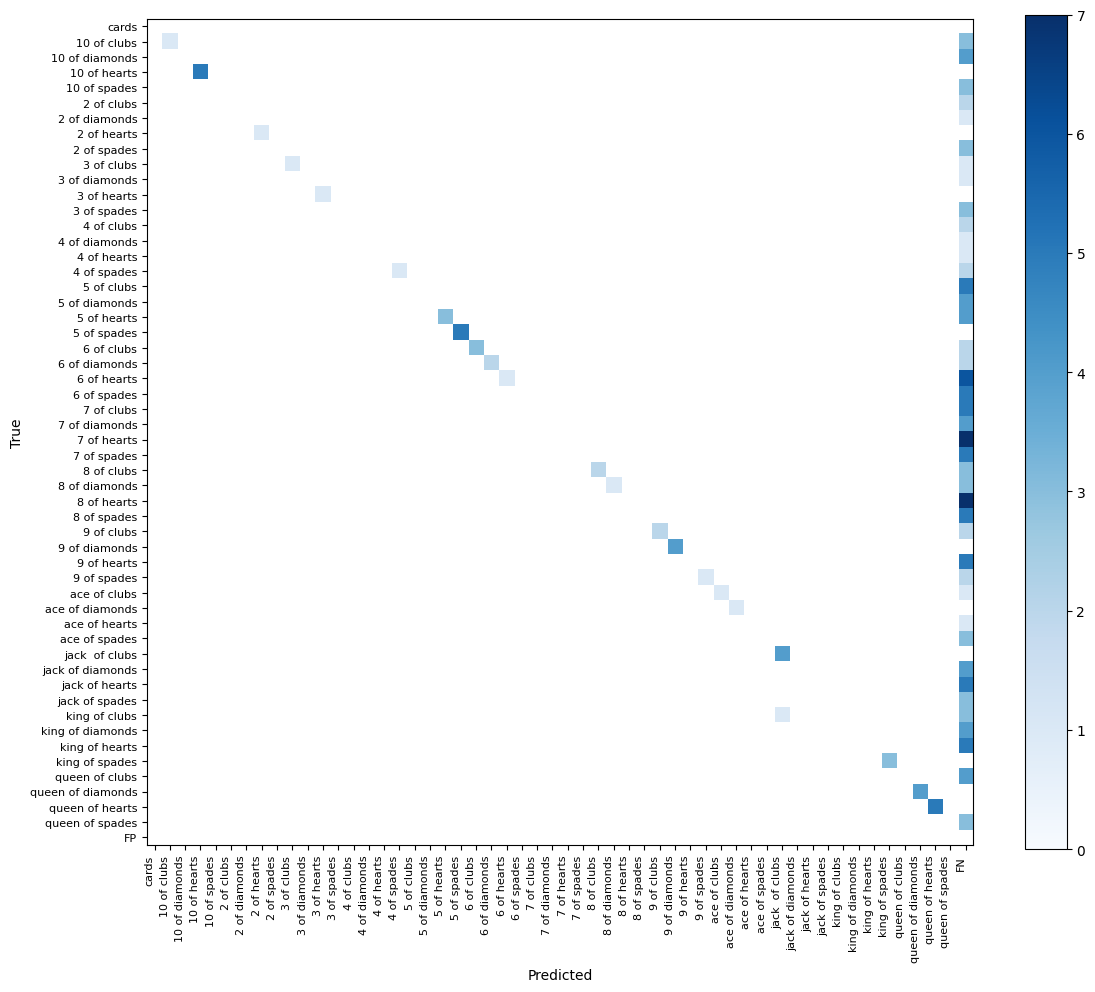

In [68]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

## Save fine-tuned model on hard drive

In [69]:
model.save_pretrained("/content/rt-detr/")
processor.save_pretrained("/content/rt-detr/")

['/content/rt-detr/preprocessor_config.json']

## Inference with fine-tuned RT-DETR model

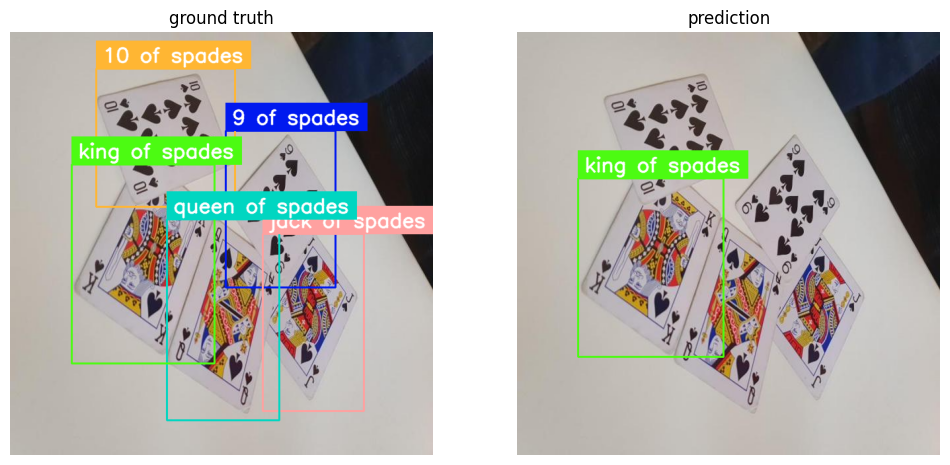

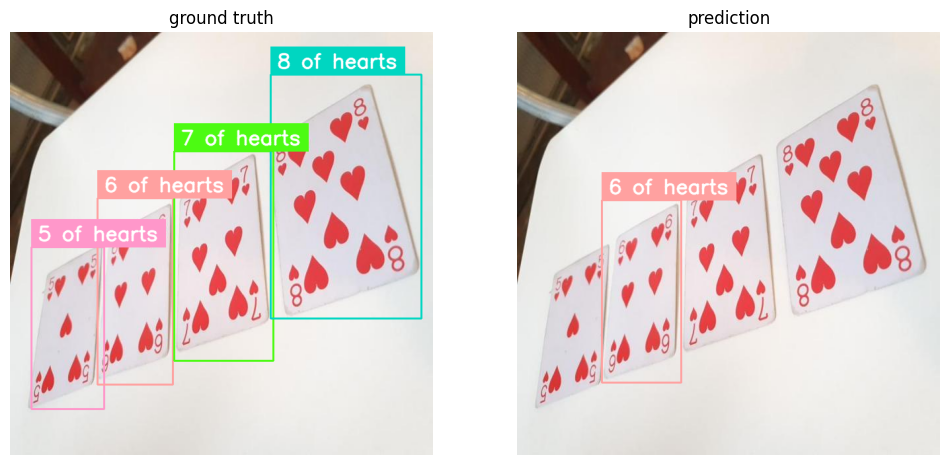

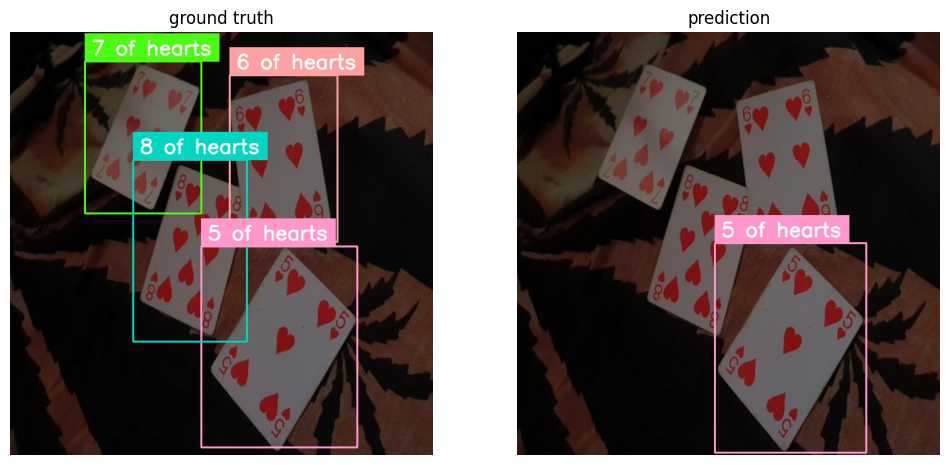

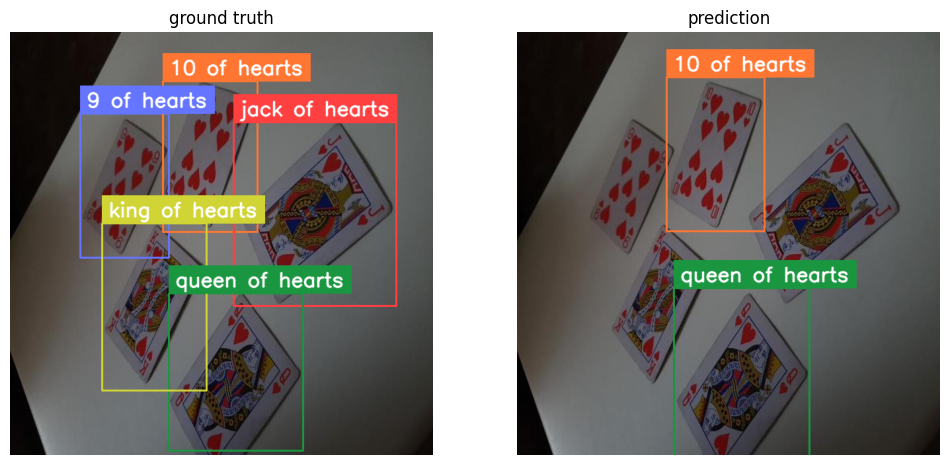

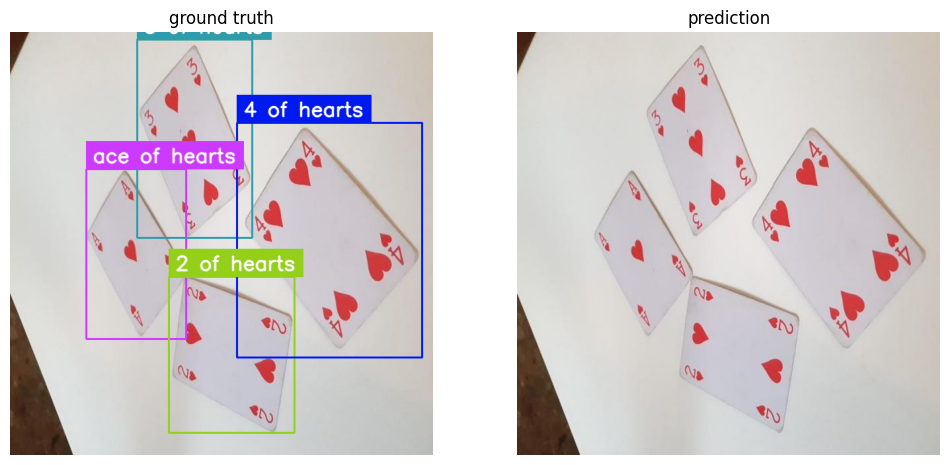

In [59]:
IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(sourece_image, annotations, ds_train.classes),
        annotate(sourece_image, detections, ds_train.classes)
    ]
    sv.plot_images_grid(
        images=annotated_images,
        grid_size=(1, 2),
        titles=['ground truth', 'prediction']
    )

No detections to display a heatmap for. Displaying original image.


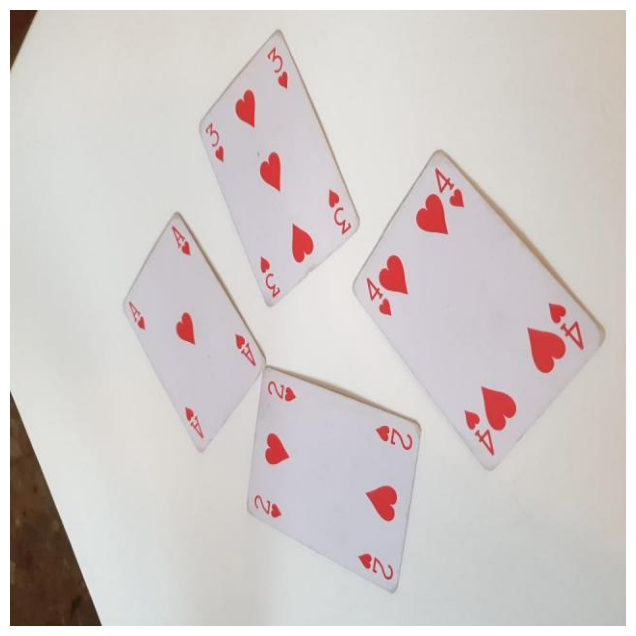

In [60]:
if len(detections) > 0:
    heatmap_annotator = sv.HeatMapAnnotator()
    annotated_image_with_heatmap = heatmap_annotator.annotate(image.copy(), detections)
    sv.plot_image(annotated_image_with_heatmap, size=(8, 8))
else:
    print("No detections to display a heatmap for. Displaying original image.")
    sv.plot_image(image.copy(), size=(8, 8))

In [61]:
import pprint

log_history = trainer.state.log_history

epoch_80_metrics = None
for entry in log_history:
    if 'epoch' in entry and entry['epoch'] == 80.0:
        epoch_80_metrics = entry
        break

if epoch_80_metrics:
    print(f"Evaluation Metrics for Epoch {epoch_80_metrics['epoch']}:")

    # Select general important metrics
    top_metrics = {
        'eval_loss': epoch_80_metrics.get('eval_loss'),
        'eval_map': epoch_80_metrics.get('eval_map'),
        'eval_map_50': epoch_80_metrics.get('eval_map_50'),
        'eval_map_75': epoch_80_metrics.get('eval_map_75'),
        'eval_mar_100': epoch_80_metrics.get('eval_mar_100')
    }

    # Collect class-specific mAP metrics, excluding 'cards' and other special ones
    class_map_metrics = {
        k: v for k, v in epoch_80_metrics.items()
        if k.startswith('eval_map_') and k not in ['eval_map', 'eval_map_50', 'eval_map_75', 'eval_map_small', 'eval_map_medium', 'eval_map_large', 'eval_map_cards']
    }

    # Sort class-specific mAP metrics and get the top 5
    sorted_class_map = sorted(class_map_metrics.items(), key=lambda item: item[1], reverse=True)[:5]

    # Add top class-specific metrics to the top_metrics dictionary
    for k, v in sorted_class_map:
        top_metrics[k] = v

    pprint.pprint(top_metrics)
else:
    print("Metrics for epoch 80.0 not found in log history.")

Metrics for epoch 80.0 not found in log history.
